# Ticket Sales — Exploratory Data Analysis

**Goal of this notebook:** look at the two-year sales export the way an analyst would on day one — figure out what's in the data, where the money is, where the *risk* is, and pick out the three or four things that would actually change a decision if a stakeholder saw them.

We're going to walk through it as a story, not a feature dump:

1. **The shape of the data** — what are we looking at?
2. **The headline** — top-line YoY movement.
3. **Who's winning, who's bleeding** — affiliate-level wins and warning signs.
4. **Where the margin lives** — ticket type, sport, marketplace, lead time.
5. **Risk pockets** — undelivered, cancellations, loss-making orders.
6. **What the dashboard misses** — observations the canned views can't easily surface.

Every chart here is also reachable interactively in the Streamlit dashboard (`streamlit run app.py`) — this notebook is the static version with commentary.

In [1]:
# Pure pandas / matplotlib stack — works on Windows / Mac / Linux. Paths
# resolved with os.path.join so it doesn't matter whether you're on a
# Unix shell or PowerShell.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cleaner
import viz

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Two color constants we'll reuse throughout — same blue/gray pair as
# the dashboard so visual continuity holds if you flip between the
# notebook and the Streamlit app.
C_THIS = '#2E86DE'
C_LAST = '#A4B0BE'
C_GOOD = '#15803D'
C_BAD  = '#B91C1C'

## 1. The shape of the data

First question on any dataset: how many rows, what columns, what's the time window, where are the holes? Before we answer any business questions we want to know the playing field.

In [2]:
this_path = '../data/this_samp.csv'

last_path = '../data/last_samp.csv'

df = cleaner.load_combined(this_path, last_path)

print(f'Total rows: {len(df):,}')
print(f'Columns:    {df.shape[1]}')
print(f'\nDate range:')
print(f'  SellDate:  {df["SellDate_dt"].min().date()}  →  {df["SellDate_dt"].max().date()}')
print(f'  EventDate: {df["EventDate_dt"].min().date()}  →  {df["EventDate_dt"].max().date()}')
print(f'\nYear split:')
print(df['YearLabel'].value_counts())

/Users/josephcohen/Documents/Career/Knopf/Data_Proj_1/python_dashboard/cleaner.py:254: DtypeWarning: Columns (37,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/Users/josephcohen/Documents/Career/Knopf/Data_Proj_1/python_dashboard/cleaner.py:254: DtypeWarning: Columns (37,43,44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Total rows: 534,478
Columns:    72

Date range:
  SellDate:  2024-05-06  →  2026-05-01
  EventDate: 2024-08-08  →  2026-04-30

Year split:
YearLabel
This Year    272080
Last Year    262398
Name: count, dtype: int64


In [ ]:
# Missingness scan — only show columns that actually have nulls
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct})

**Reading the missingness table:** a high null rate isn't automatically a problem — it depends on what the column means. `SecondaryPerformerName` being null usually just means "no opening act". `EventDate_dt` being null is more concerning because it disables the lead-time analysis for those rows.

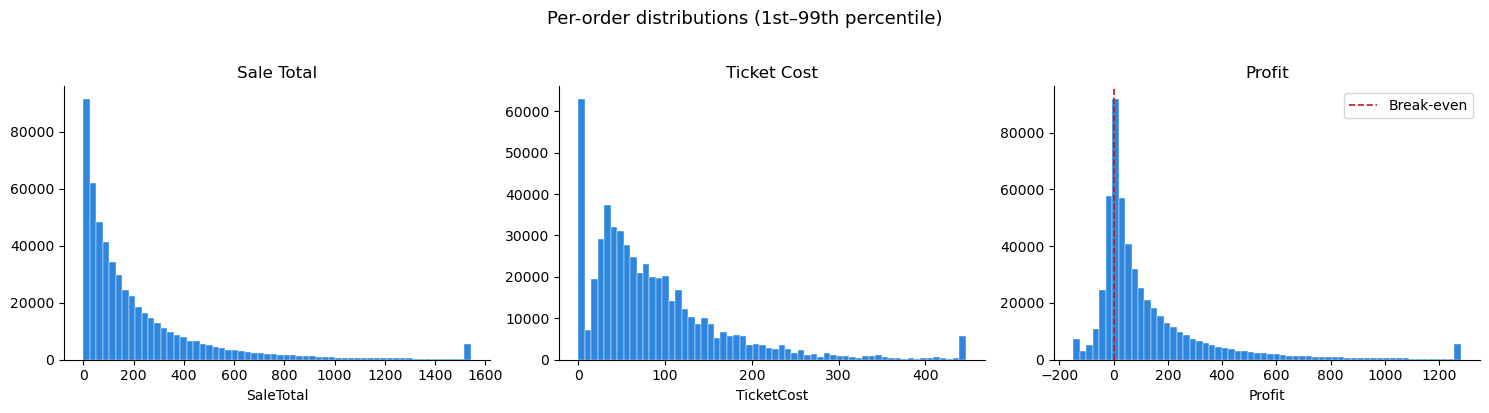

In [5]:
# Quick distribution snapshot of the three money columns. Bounded at the
# 99th percentile because there are always a few outsized orders that
# would otherwise blow up the x-axis.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                          ['SaleTotal', 'TicketCost', 'Profit'],
                          ['Sale Total', 'Ticket Cost', 'Profit']):
    series = df[col].dropna()
    p99 = series.quantile(0.99)
    p1  = series.quantile(0.01) if col == 'Profit' else 0
    ax.hist(series.clip(p1, p99), bins=60, color=C_THIS, edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel(col)
    if col == 'Profit':
        ax.axvline(0, color=C_BAD, linestyle='--', linewidth=1.2, label='Break-even')
        ax.legend()
plt.suptitle('Per-order distributions (1st–99th percentile)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Notes from the per-order distributions:**

- The bulk of orders are small dollar values — the long right tail is what generates a disproportionate share of revenue.
- The Profit histogram has visible mass *to the left of zero* — these are the loss-making orders. Section 5 below digs into them.
- `TicketCost` and `SaleTotal` shapes look similar, which is expected since they're correlated.

## 2. The headline — top-line YoY

The most important slide in any business review: are we up or down on the year, and on what dimensions?

In [6]:
this_df, last_df = cleaner.split_years(df)
this_kpi = cleaner.kpi_block(this_df)
last_kpi = cleaner.kpi_block(last_df)

headline = pd.DataFrame({
    'Last Year':  [last_kpi['revenue'], last_kpi['profit'], last_kpi['margin'],
                   last_kpi['orders'],  last_kpi['tickets']],
    'This Year':  [this_kpi['revenue'], this_kpi['profit'], this_kpi['margin'],
                   this_kpi['orders'],  this_kpi['tickets']],
}, index=['Revenue', 'Profit', 'Margin %', 'Orders', 'Tickets Sold'])
headline['YoY %'] = (headline['This Year'] - headline['Last Year']) / headline['Last Year'].abs() * 100
# Margin difference is in percentage points, not %
headline.loc['Margin %', 'YoY %'] = headline.loc['Margin %', 'This Year'] - headline.loc['Margin %', 'Last Year']
headline.round(2)

,Last Year,This Year,YoY %
Revenue,"59,483,647.71","60,832,276.20",2.27
Profit,"36,121,220.05","36,258,475.71",0.38
Margin %,60.72,59.60,-1.12
Orders,"262,398.00","272,080.00",3.69
Tickets Sold,"638,164.00","662,105.00",3.75


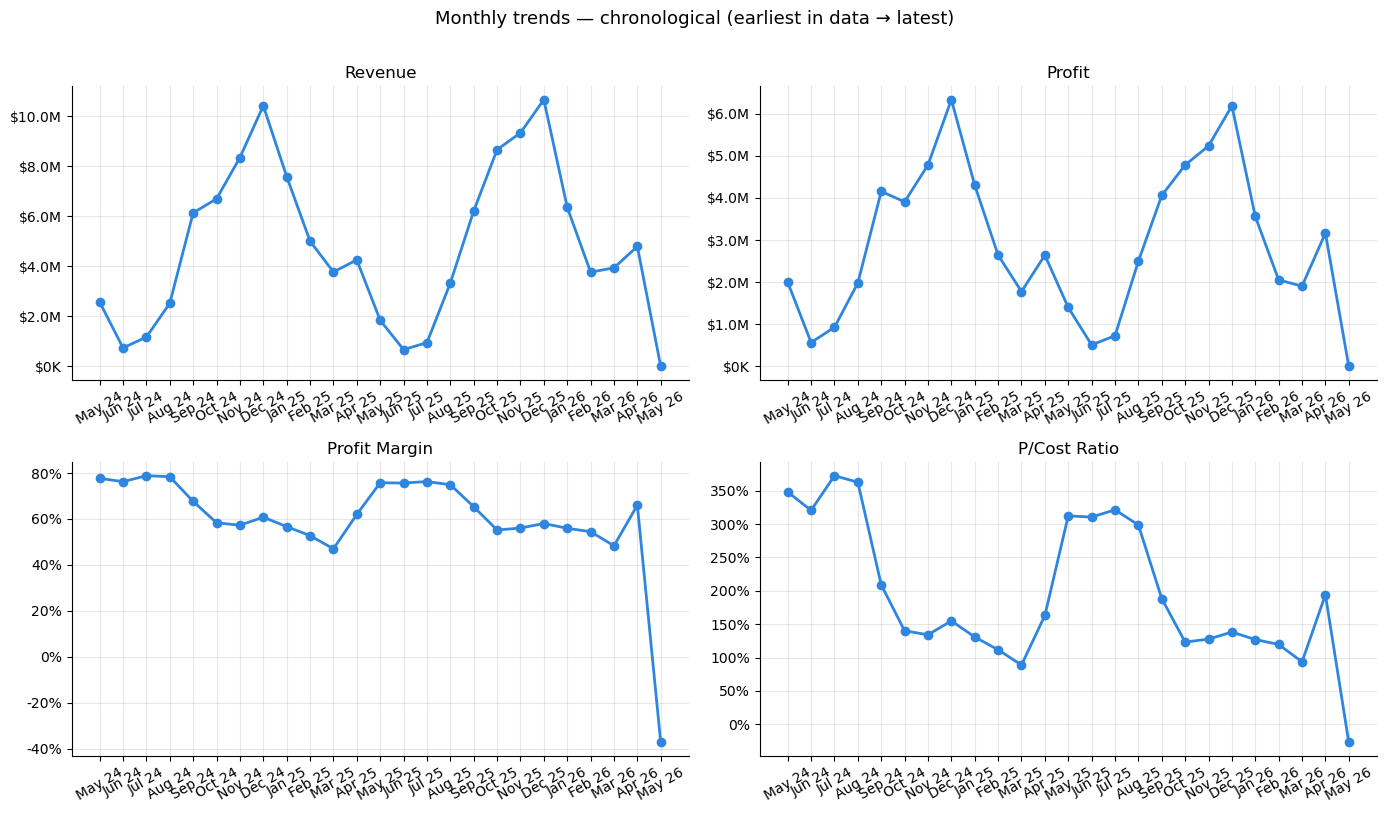

In [7]:
# Monthly trend — chronological from the earliest month in the data to
# the latest. This is the picture that should tell you most of the story
# at a glance. Single line, no two-year overlay (the per-period YoY is
# in the table above + the seasonal shape is in the line itself).

work = df.dropna(subset=['SellDate_dt']).copy()
work['YearMonth'] = work['SellDate_dt'].dt.to_period('M')
monthly = (work.groupby('YearMonth')
             .agg(rev=('SaleTotal', 'sum'),
                  prof=('Profit', 'sum'),
                  cost=('TicketCost', 'sum'),
                  orders=('SaleTotal', 'count'))
             .reset_index())
monthly['Margin %']        = (monthly['prof'] / monthly['rev']) * 100
monthly['P/Cost Ratio %']  = (monthly['prof'] / monthly['cost']) * 100
monthly['Label'] = monthly['YearMonth'].apply(lambda p: p.strftime('%b %y'))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, title in zip(axes.flatten(),
                          ['rev', 'prof', 'Margin %', 'P/Cost Ratio %'],
                          ['Revenue', 'Profit', 'Profit Margin', 'P/Cost Ratio']):
    ax.plot(monthly['Label'], monthly[col], marker='o', color=C_THIS,
            linewidth=2, markersize=6)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)
    if col in ('rev', 'prof'):
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    else:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.suptitle('Monthly trends — chronological (earliest in data → latest)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**What to look for in the monthly chart:**

- **Slope changes within each metric.** Revenue can grow while margin shrinks — that's a discounting story. Margin can grow while orders shrink — that's a quality-over-quantity story.
- **Sport seasonality.** NFL is fall/winter, NBA/NHL are winter/spring, MLB is spring/summer. A monthly dip might be sport-mix shifting, not real demand collapse.
- **The Profit/Cost ratio (bottom right) is often the most stable metric.** Big monthly revenue swings can be explained by sport mix or a single big tour; a structural drop in the ratio means margins are compressing across the board.

## 3. Who's winning, who's bleeding

The portfolio average hides everything important. Two affiliates can both grow 10% YoY for very different reasons — one is gaining new venues, the other is just absorbing volume from a competitor that quit. Let's pull the affiliate-level picture apart.

In [8]:
# Use the same aggregation logic as the dashboard (sum-then-divide for
# margin/ratio — no row-averaging that would weight a $5 ticket the same
# as a $5,000 one).
aff_table = viz.groupby_yoy_table(df, 'CompanyName')
aff_table.head(15)

,CompanyName,Revenue (TY),Revenue (LY),Revenue YoY %,Profit (TY),Profit (LY),Profit YoY %,Margin % (TY),Margin % (LY),P/Cost Ratio % (TY),P/Cost Ratio % (LY),Orders (TY),Orders (LY)
0,YS-Seatgeek2,"25,192,672.63","19,960,004.85",26.20,"14,379,834.59","11,682,442.06",23.10,57.10,58.50,133.00,141.10,133585,108873
1,Levovitz,"6,891,653.77","8,923,224.33",-22.80,"3,712,444.57","4,564,753.66",-18.70,53.90,51.20,116.80,104.70,15843,21644
2,GK LLC,"5,776,162.93","4,962,258.35",16.40,"3,845,996.93","3,426,620.24",12.20,66.60,69.10,199.30,223.10,25558,21829
3,YSS Tickets,"5,246,119.15","4,861,329.39",7.90,"3,306,953.94","3,078,854.79",7.40,63.00,63.30,170.50,172.70,21357,20679
4,Yoni Levine,"4,078,487.77","3,750,528.99",8.70,"2,731,528.89","2,505,896.12",9.00,67.00,66.80,202.80,201.30,16072,14694
5,Pollak Tickets,"3,281,915.09","3,474,309.66",-5.50,"2,062,572.03","2,285,438.41",-9.80,62.80,65.80,169.20,192.20,14976,15230
6,YSM Tickets,"3,121,284.59","3,076,094.20",1.50,"1,828,293.68","1,822,436.82",0.30,58.60,59.20,141.40,145.40,13446,14010
7,YS Tickets,"2,669,357.46","6,297,231.44",-57.60,"1,966,740.64","4,454,859.48",-55.90,73.70,70.70,279.90,241.80,11475,27526
8,Jacks YS,"2,268,913.17","1,764,358.40",28.60,"1,135,871.17","864,055.45",31.50,50.10,49.00,100.20,96.00,8448,6513
9,YS Katz,"1,905,519.92","1,637,719.28",16.40,"1,011,186.48","961,086.65",5.20,53.10,58.70,113.10,142.00,8053,6533


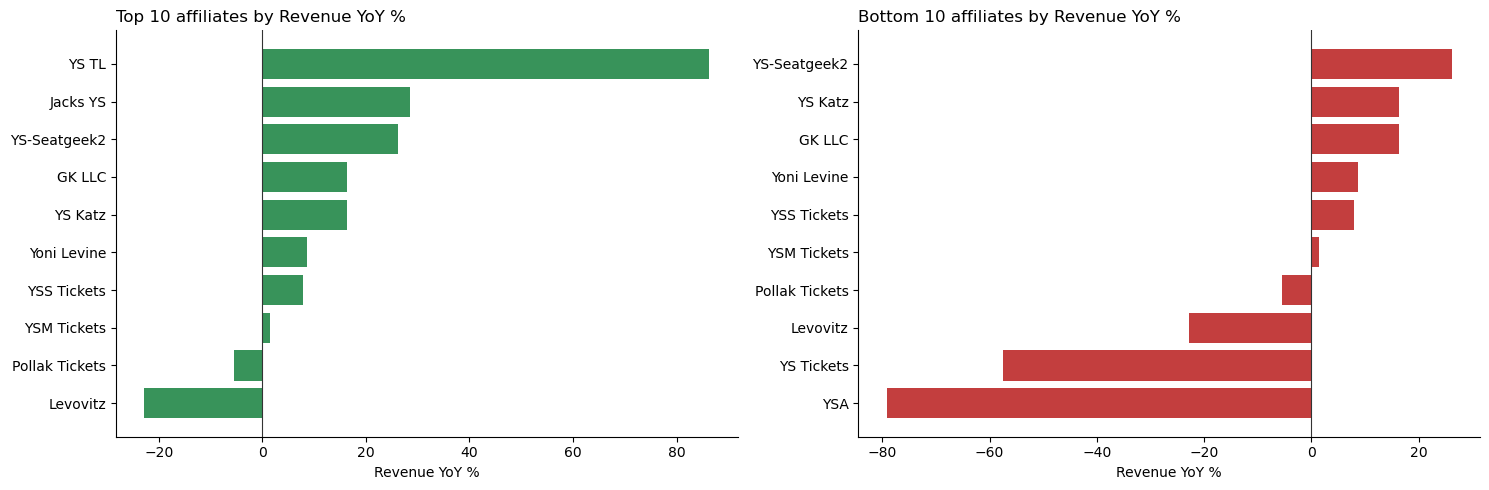

Note: affiliates with <$1K last-year revenue excluded — their YoY% is a divide-by-tiny.


In [9]:
# Two-panel: revenue YoY winners and losers, side by side, sorted by magnitude
valid = aff_table.dropna(subset=['Revenue YoY %']).copy()
valid = valid[valid['Revenue (LY)'] > 1000]   # ignore tiny-base affiliates where YoY% is a divide-by-tiny
winners = valid.nlargest(10, 'Revenue YoY %')
losers  = valid.nsmallest(10, 'Revenue YoY %')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(winners['CompanyName'][::-1], winners['Revenue YoY %'][::-1],
             color=C_GOOD, alpha=0.85)
axes[0].set_title('Top 10 affiliates by Revenue YoY %', loc='left')
axes[0].set_xlabel('Revenue YoY %')
axes[0].axvline(0, color='#333', linewidth=0.8)

axes[1].barh(losers['CompanyName'], losers['Revenue YoY %'], color=C_BAD, alpha=0.85)
axes[1].set_title('Bottom 10 affiliates by Revenue YoY %', loc='left')
axes[1].set_xlabel('Revenue YoY %')
axes[1].axvline(0, color='#333', linewidth=0.8)

plt.tight_layout()
plt.show()

print('Note: affiliates with <$1K last-year revenue excluded — their YoY% is a divide-by-tiny.')

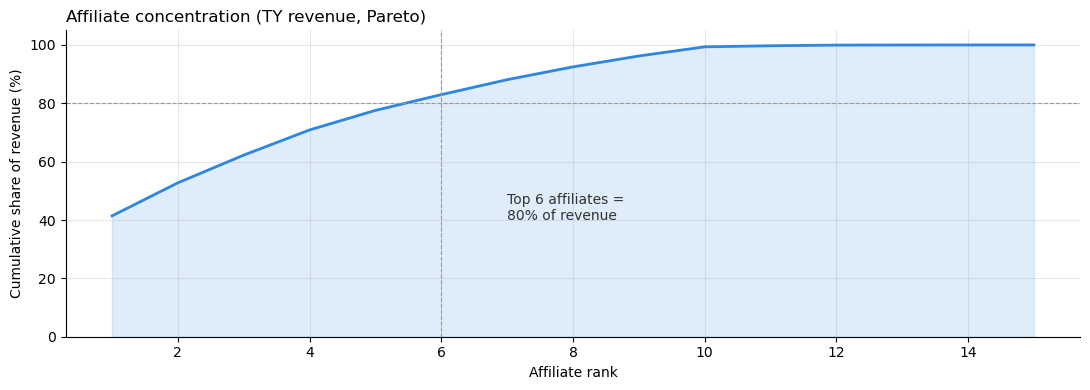

Total affiliates this year: 15
Largest single affiliate share: 41.4%


In [10]:
# Now the Pareto picture. How concentrated is revenue across affiliates?
this_aff = (this_df.groupby('CompanyName')['SaleTotal'].sum()
                   .sort_values(ascending=False).reset_index())
this_aff['cumshare'] = this_aff['SaleTotal'].cumsum() / this_aff['SaleTotal'].sum() * 100
this_aff['rank'] = range(1, len(this_aff) + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(this_aff['rank'], this_aff['cumshare'], color=C_THIS, linewidth=2)
ax.fill_between(this_aff['rank'], 0, this_aff['cumshare'], color=C_THIS, alpha=0.15)
ax.axhline(80, color='#999', linestyle='--', linewidth=0.8)
# Find rank crossing 80%
if (this_aff['cumshare'] >= 80).any():
    pareto_rank = int(this_aff[this_aff['cumshare'] >= 80].iloc[0]['rank'])
    ax.axvline(pareto_rank, color='#999', linestyle='--', linewidth=0.8)
    ax.text(pareto_rank + 1, 40, f'Top {pareto_rank} affiliates =\n80% of revenue',
            color='#333', fontsize=10)
ax.set_title('Affiliate concentration (TY revenue, Pareto)', loc='left')
ax.set_xlabel('Affiliate rank')
ax.set_ylabel('Cumulative share of revenue (%)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total affiliates this year: {len(this_aff)}')
print(f'Largest single affiliate share: {this_aff.iloc[0]["SaleTotal"] / this_aff["SaleTotal"].sum() * 100:.1f}%')

**The Pareto chart answers a question that doesn't show up cleanly anywhere in the dashboard:** how many partners would we lose 80% of revenue with if they all walked away? That single number is one of the more useful framings for affiliate-strategy conversations.

## 4. Where the margin lives

Revenue tells you what's selling. Margin tells you what's *worth* selling. We're going to slice margin five different ways and see which dimension actually moves the needle.

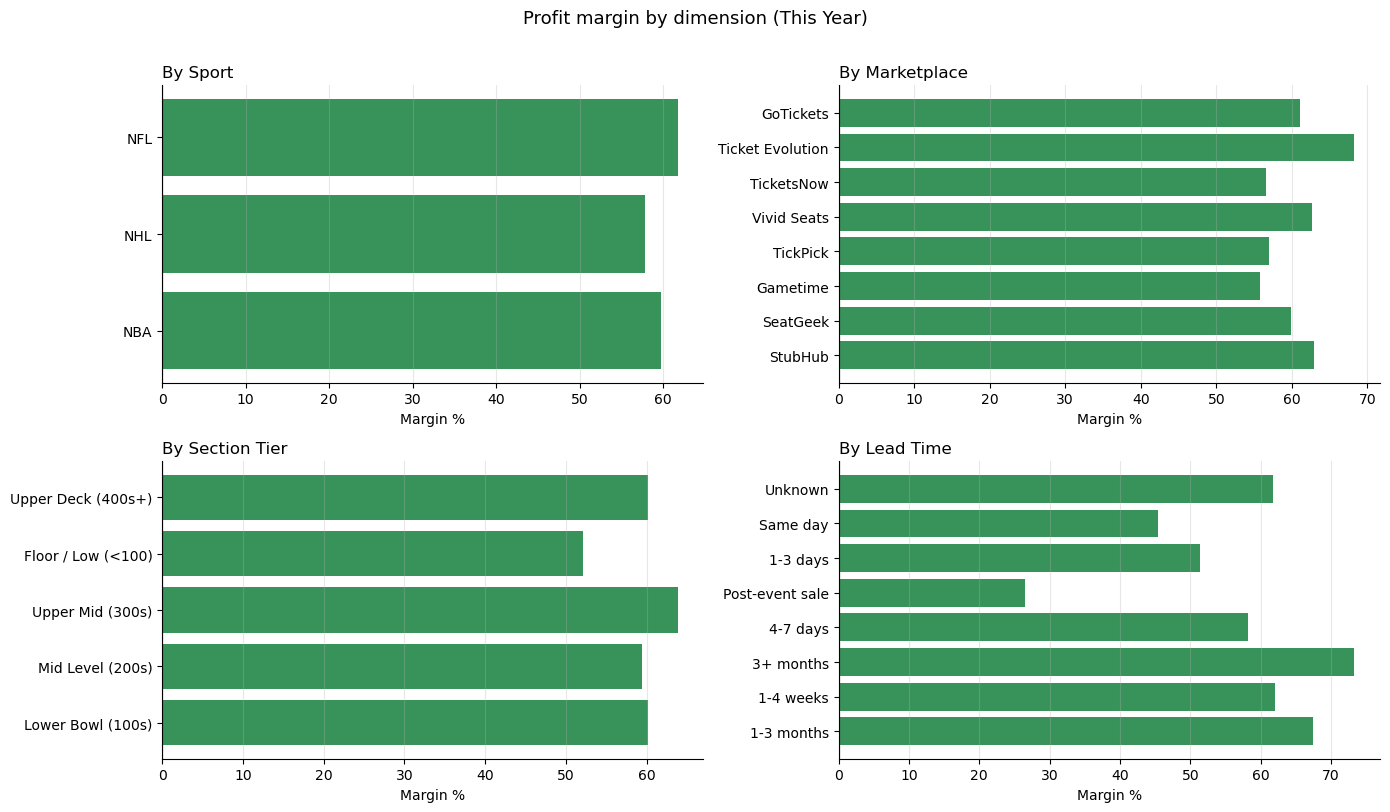

In [11]:
# Helper to compute proper aggregate margin per group
def margin_summary(frame, group_col):
    g = (frame.groupby(group_col)
              .agg(rev=('SaleTotal', 'sum'),
                   prof=('Profit', 'sum'),
                   cost=('TicketCost', 'sum'),
                   orders=('SaleTotal', 'count'))
              .reset_index())
    g['Margin %']       = np.where(g['rev'] > 0, g['prof'] / g['rev'] * 100, 0)
    g['P/Cost Ratio %'] = np.where(g['cost'] > 0, g['prof'] / g['cost'] * 100, 0)
    return g.sort_values('rev', ascending=False)

# By sport
by_sport = margin_summary(this_df, 'Sport')
by_mkt   = margin_summary(this_df, 'ShippingCompany').head(8)
by_tier  = margin_summary(this_df, 'SectionNumTier')
by_lead  = margin_summary(this_df, 'LeadTimeBucket')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, frame, dim_col, title in zip(
        axes.flatten(), [by_sport, by_mkt, by_tier, by_lead],
        ['Sport', 'ShippingCompany', 'SectionNumTier', 'LeadTimeBucket'],
        ['By Sport', 'By Marketplace', 'By Section Tier', 'By Lead Time']):
    colors = [C_GOOD if v >= 0 else C_BAD for v in frame['Margin %']]
    ax.barh(frame[dim_col].astype(str), frame['Margin %'], color=colors, alpha=0.85)
    ax.set_title(title, loc='left')
    ax.set_xlabel('Margin %')
    ax.axvline(0, color='#333', linewidth=0.8)
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle('Profit margin by dimension (This Year)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**What the four panels are telling us:**

- **Sport** is the easiest to scope but has the smallest margin spread between the best and worst leagues — most leagues land in a similar band.
- **Marketplace** has wider variance. Tier 3 / B2B venues often have meaningfully different margin economics from the consumer marketplaces.
- **Section tier** is where premium pricing shows up. If the upper deck has low margin and the floor has high margin, that's a pricing-power story.
- **Lead time** is the single most actionable dimension. Same-day sales typically have the worst margins (you're closing out at any price); same-week sales have the best (urgency without panic). If your data reproduces that pattern, the buying team has a clear lever — *acquire later, sell earlier*.

In [12]:
# Confirm the lead-time hypothesis quantitatively. Group by week-buckets.
lt = this_df.dropna(subset=['LeadTimeDays', 'ProfitMargin']).copy()
lt['lt_bucket'] = pd.cut(lt['LeadTimeDays'],
                          bins=[-1, 0, 1, 3, 7, 14, 30, 60, 365, 9999],
                          labels=['Same day','1 day','2-3 days','4-7 days',
                                  '1-2 weeks','2-4 weeks','1-2 months','2-12 months','1y+'])
lt_summary = (lt.groupby('lt_bucket', observed=True)
                .agg(orders=('SaleTotal', 'count'),
                     median_margin=('ProfitMargin', 'median'),
                     agg_margin=('Profit', lambda s: s.sum() / lt.loc[s.index, 'SaleTotal'].sum() * 100))
                .reset_index())
lt_summary

,lt_bucket,orders,median_margin,agg_margin
0,Same day,16364,34.10,45.49
1,1 day,11573,40.06,48.84
2,2-3 days,17702,46.09,52.97
3,4-7 days,27391,49.87,58.22
4,1-2 weeks,29929,53.04,60.65
5,2-4 weeks,39664,54.58,63.00
6,1-2 months,37670,58.82,66.58
7,2-12 months,35965,64.22,71.35


## 5. Risk pockets

Money you didn't make is just as important as money you did make. Three risk vectors to surface: **loss-making orders**, **undelivered orders** (revenue that books but doesn't fulfill), and **cancellations**.

In [13]:
# Loss-making orders profile
losses = df[df['Profit'] < 0]
loss_aff = (losses.groupby('CompanyName')
                  .agg(loss_orders=('Profit', 'count'),
                       loss_dollars=('Profit', 'sum'),
                       median_loss=('Profit', 'median'))
                  .reset_index()
                  .sort_values('loss_dollars'))
loss_aff['Total orders']    = loss_aff['CompanyName'].map(df.groupby('CompanyName').size())
loss_aff['Loss-order %']    = (loss_aff['loss_orders'] / loss_aff['Total orders'] * 100).round(1)
loss_aff = loss_aff[loss_aff['Total orders'] >= 50]   # cut tiny-base noise
loss_aff.head(15)

,CompanyName,loss_orders,loss_dollars,median_loss,Total orders,Loss-order %
7,YS-Seatgeek2,67615,"-2,200,613.53",-21.62,242458,27.90
2,Levovitz,10808,"-1,073,639.01",-57.21,37487,28.80
6,YS Tickets,5225,"-263,278.94",-29.04,39001,13.40
1,Jacks YS,2633,"-260,041.55",-51.31,14961,17.60
11,YSS Tickets,8005,"-256,883.85",-21.64,42036,19.00
4,YS Katz,3884,"-254,706.22",-45.00,14586,26.60
0,GK LLC,8318,"-206,858.74",-18.76,47387,17.60
10,YSM Tickets,5050,"-188,538.03",-22.21,27456,18.40
3,Pollak Tickets,5335,"-169,865.93",-20.68,30206,17.70
13,Yoni Levine,4693,"-150,882.19",-20.31,30766,15.30


In [14]:
# Where does ALL of the loss come from? Often it's surprisingly
# concentrated in a handful of affiliates / sports / venues.
total_loss = losses['Profit'].sum()
print(f'Total loss across all loss-making orders: ${total_loss:,.0f}')
print(f'Number of loss-making orders:             {len(losses):,}')
print(f'Average loss per such order:              ${total_loss/len(losses):,.0f}')
print()

# Top-5 affiliates by absolute loss dollars
top_lossers = (losses.groupby('CompanyName')['Profit'].sum()
                     .sort_values().head(5))
share = top_lossers.sum() / total_loss * 100
print('Top 5 loss-contributing affiliates:')
for name, loss in top_lossers.items():
    print(f'  {name:<35}  ${loss:>12,.0f}')
print(f'\n  → these 5 represent {share:.0f}% of total losses.')

Total loss across all loss-making orders: $-5,064,173
Number of loss-making orders:             123,170
Average loss per such order:              $-41

Top 5 loss-contributing affiliates:
  YS-Seatgeek2                         $  -2,200,614
  Levovitz                             $  -1,073,639
  YS Tickets                           $    -263,279
  Jacks YS                             $    -260,042
  YSS Tickets                          $    -256,884

  → these 5 represent 80% of total losses.


**Why this matters for the conversation:** if loss is heavily concentrated in a few affiliates, that's a tactical fix — talk to those partners specifically. If it's spread evenly across the portfolio, the issue is structural and probably lives in pricing rules or in a specific marketplace policy.

In [15]:
# Undelivered orders this year
if 'IsDelivered' in df.columns:
    und = this_df[~this_df['IsDelivered'].fillna(False)]
    print(f'Undelivered orders TY: {len(und):,}')
    print(f'Lost revenue:          ${und["SaleTotal"].sum():,.0f}')
    print(f'Delivery rate:         {(1 - len(und)/len(this_df))*100:.2f}%')
    print()
    und_aff = (und.groupby('CompanyName')
                  .agg(Undelivered=('SaleTotal', 'count'),
                       LostRevenue=('SaleTotal', 'sum'))
                  .reset_index()
                  .sort_values('LostRevenue', ascending=False)
                  .head(10))
    print('Top 10 affiliates by lost (undelivered) revenue:')
    print(und_aff.to_string(index=False))

Undelivered orders TY: 12,400
Lost revenue:          $32,774
Delivery rate:         95.44%

Top 10 affiliates by lost (undelivered) revenue:
   CompanyName  Undelivered  LostRevenue
  YS-Seatgeek2         4418    16,668.34
       YS Katz         1164     5,100.10
        GK LLC         1815     4,413.20
   Yoni Levine         1033     2,240.57
      Levovitz          194     2,135.95
   YSM Tickets          635       646.54
   YSS Tickets          703       592.23
Pollak Tickets          971       537.26
      Jacks YS          483       225.00
    YS Tickets          874       214.36


## 6. What the dashboard misses — three observations

The dashboard is built around the standard cuts: by affiliate, sport, marketplace, time period. There are some second-order patterns it doesn't surface as easily — these are usually where the *interesting* findings live.

In [16]:
# Observation 1: Average order size is shifting.
# Even if revenue is flat YoY, a shift in average ticket cost can mean
# we're servicing different price points. Easy to miss because total
# revenue doesn't change.

ty_avg = this_df['SaleTotal'].mean()
ly_avg = last_df['SaleTotal'].mean()
ty_med = this_df['SaleTotal'].median()
ly_med = last_df['SaleTotal'].median()
ty_q90 = this_df['SaleTotal'].quantile(0.90)
ly_q90 = last_df['SaleTotal'].quantile(0.90)

print('Order-size shift:')
print(f'                 LY        TY        change')
print(f'  Mean      ${ly_avg:>8,.0f}  ${ty_avg:>8,.0f}    {(ty_avg/ly_avg-1)*100:+.1f}%')
print(f'  Median    ${ly_med:>8,.0f}  ${ty_med:>8,.0f}    {(ty_med/ly_med-1)*100:+.1f}%')
print(f'  P90       ${ly_q90:>8,.0f}  ${ty_q90:>8,.0f}    {(ty_q90/ly_q90-1)*100:+.1f}%')
print()
print('Mean moving differently from median = distribution shape is changing.')
print('If P90 grew faster than median, the long tail is doing more of the work.')

Order-size shift:
                 LY        TY        change
  Mean      $     227  $     224    -1.4%
  Median    $     120  $     121    +0.5%
  P90       $     536  $     533    -0.6%

Mean moving differently from median = distribution shape is changing.
If P90 grew faster than median, the long tail is doing more of the work.


In [17]:
# Observation 2: Sport mix shift, decomposed.
# Total revenue YoY = (volume change in each sport) * (mix change in each sport).
# Splitting the two tells you whether "NBA grew" or "we sold more NBA tickets
# because we sold less of everything else."

sport_yoy = (df.groupby(['Sport', 'YearLabel'])['SaleTotal']
               .sum().unstack(fill_value=0))
if 'This Year' in sport_yoy.columns and 'Last Year' in sport_yoy.columns:
    sport_yoy['YoY %']     = (sport_yoy['This Year'] - sport_yoy['Last Year']) / sport_yoy['Last Year'].replace(0, np.nan) * 100
    sport_yoy['LY share %'] = sport_yoy['Last Year'] / sport_yoy['Last Year'].sum() * 100
    sport_yoy['TY share %'] = sport_yoy['This Year'] / sport_yoy['This Year'].sum() * 100
    sport_yoy['Share Δ pp'] = (sport_yoy['TY share %'] - sport_yoy['LY share %']).round(2)
    print(sport_yoy.round(1))
    print('\nShare Δ pp (percentage points) — positive = sport gaining share, negative = losing share.')
    print('A sport can have positive YoY% but negative share Δ if the rest of the portfolio grew faster.')

YearLabel     Last Year     This Year  YoY %  LY share %  TY share %  Share Δ pp
Sport                                                                           
NBA       24,048,950.70 26,369,271.40   9.60       40.40       43.30        2.90
NFL       17,860,887.60 14,638,837.10 -18.00       30.00       24.10       -6.00
NHL       17,573,809.40 19,824,167.70  12.80       29.50       32.60        3.00

Share Δ pp (percentage points) — positive = sport gaining share, negative = losing share.
A sport can have positive YoY% but negative share Δ if the rest of the portfolio grew faster.


In [18]:
# Observation 3: Affiliate × sport health — which combinations are
# silently bleeding margin?

aff_sport = (this_df.groupby(['CompanyName', 'Sport'])
                    .agg(rev=('SaleTotal', 'sum'),
                         prof=('Profit', 'sum'),
                         orders=('SaleTotal', 'count'))
                    .reset_index())
aff_sport['Margin %'] = np.where(aff_sport['rev'] > 0, aff_sport['prof'] / aff_sport['rev'] * 100, 0)
# Filter to material combinations (>= $5k revenue) so a single weird order doesn't dominate
material = aff_sport[aff_sport['rev'] >= 5000].copy()

# The combinations doing the worst on margin
worst = material.sort_values('Margin %').head(10).copy()
worst['rev'] = worst['rev'].round(0)
worst['prof'] = worst['prof'].round(0)
worst['Margin %'] = worst['Margin %'].round(1)
print('Worst affiliate × sport margin combinations (revenue ≥ $5k):')
print(worst[['CompanyName', 'Sport', 'rev', 'prof', 'orders', 'Margin %']].to_string(index=False))

Worst affiliate × sport margin combinations (revenue ≥ $5k):
CompanyName Sport          rev         prof  orders  Margin %
   Jacks YS   NHL   598,192.00   223,649.00    2709     37.40
        YSW   NHL    12,833.00     5,632.00      66     43.90
      YSA 3   NBA     6,709.00     3,359.00      17     50.10
    YS Katz   NHL   193,859.00    98,769.00    1102     50.90
 YS Tickets   NHL    74,596.00    38,331.00     593     51.40
      YS TL   NBA    31,474.00    16,204.00     366     51.50
    YS Katz   NFL 1,003,701.00   520,150.00    3741     51.80
   Levovitz   NBA 4,153,943.00 2,199,751.00    9312     53.00
YSM Tickets   NHL 1,361,782.00   737,654.00    6937     54.20
   Jacks YS   NFL   664,137.00   362,125.00    2145     54.50


**Why these three observations matter together:**

1. **Order-size shift** flags whether the customer base is changing — even when revenue looks flat.
2. **Sport mix decomposition** separates real growth from accounting growth ("we grew NBA" vs "NBA's share of a smaller pie went up").
3. **Affiliate × sport low-margin combos** is the most actionable list — these are specific (partner, league) pairs to either renegotiate, deprioritize, or investigate. The aggregated affiliate row hides them, and the aggregated sport row hides them; only the cross-tab makes them visible.

If you're presenting this dataset to a stakeholder, your three slides are the headline (Section 2), the affiliate winners/losers chart (Section 3), and the affiliate × sport low-margin table (Section 6.3).

## Summary — the story so far

Replace the bullets below with whatever the data actually said when you ran this:

- **Headline:** revenue moved [up/down] X%, profit [up/down] Y%, margin [held/expanded/compressed] by Z pp.
- **Concentration risk:** the top N affiliates account for 80% of revenue.
- **Margin lever:** lead-time bucket [matters/doesn't matter] significantly — same-day was [worst/middle/best] at K%.
- **Loss concentration:** the worst 5 affiliates contributed [share]% of total losses.
- **Where to dig next:** [specific affiliate × sport pairs] are doing [revenue] at margins below break-even — these are the first conversations to have.

From here, the interactive dashboard is the better tool — pick any of those threads and pull on it. The dashboard's YoY Trend Analysis page (with its dimension picker) is the fastest way to slice further once you know what you're looking for.

In [15]:
df['MONTH']=pd.to_datetime(df['SellMonth']).dt.month

In [16]:
aggy = {
    'Profit':'sum',
    'TicketsSold':'sum',
    'SaleTotal':'sum',
    'ProfitMargin':'mean'
}
collys = ['Profit','TicketsSold','SaleTotal','ProfitMargin','CompanyName','PrimaryPerformerName','YEAR','MONTH']
groupy = df[collys].groupby(['CompanyName','PrimaryPerformerName','YEAR','MONTH'],as_index=False).agg(aggy)

In [17]:
groupy[groupy['YEAR']=='last_year']['SaleTotal'].sum()

59265448.93000001

In [18]:
groupy.to_csv('grouped_stuff.csv')